# 04. Tactical clustering

**Question:** do club style profiles fall into clear groups, and if so, what separates them?

Uses the club-season profiles from `src/analysis/tactical.py`: per-match averages of eleven team stats, from
2018-19 onwards (older seasons are missing some of them). Clubs need four matches in a season to be included.

In [1]:
import sys
from pathlib import Path

# Let the notebook import from src/ when it's run from the notebooks folder.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.database.connection import read_sql

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.edgecolor": "#c3c2b7",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]),
})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"

In [2]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

from src.analysis.tactical import PROFILE_FEATURES, club_profiles, cluster_profiles, describe_cluster, standardize

club_matches = read_sql("SELECT * FROM v_club_matches")
profiles = club_profiles(club_matches)
print(f"{len(profiles)} club-seasons from {profiles['season'].min()} to {profiles['season'].max()}")
profiles[list(PROFILE_FEATURES)].describe().round(2)

264 club-seasons from 2018-19 to 2025-26


,possession_pct,passes,pass_completion,long_ball_share,crosses,shots,shots_against,tackles,interceptions,clearances,fouls
count,264.00,264.00,264.00,264.00,264.00,264.00,264.00,264.00,264.00,264.00,264.00
mean,48.74,477.72,0.83,0.11,15.71,12.63,13.34,16.74,10.34,17.96,11.54
std,7.64,92.63,0.04,0.03,3.96,3.03,3.30,2.50,2.44,5.07,2.10
min,28.90,265.50,0.71,0.04,6.50,6.00,6.46,10.50,5.00,7.12,6.40
25%,43.65,411.50,0.80,0.09,12.80,10.50,11.05,14.88,8.58,14.70,10.17
50%,48.68,467.74,0.83,0.11,15.55,12.55,12.89,16.68,10.00,17.50,11.33
75%,53.43,531.83,0.86,0.13,18.00,14.71,15.42,18.21,11.60,20.75,12.67
max,69.99,766.60,0.92,0.20,27.12,21.91,24.00,25.67,18.33,34.17,18.17


## Correlations between the stats

Clustering on highly correlated features effectively counts the same thing twice, so it's worth looking first.

long_ball_share   -0.75
shots_against     -0.64
clearances        -0.63
interceptions     -0.27
tackles           -0.16
fouls             -0.12
crosses            0.45
shots              0.70
pass_completion    0.78
passes             0.90
possession_pct     1.00
Name: possession_pct, dtype: float64

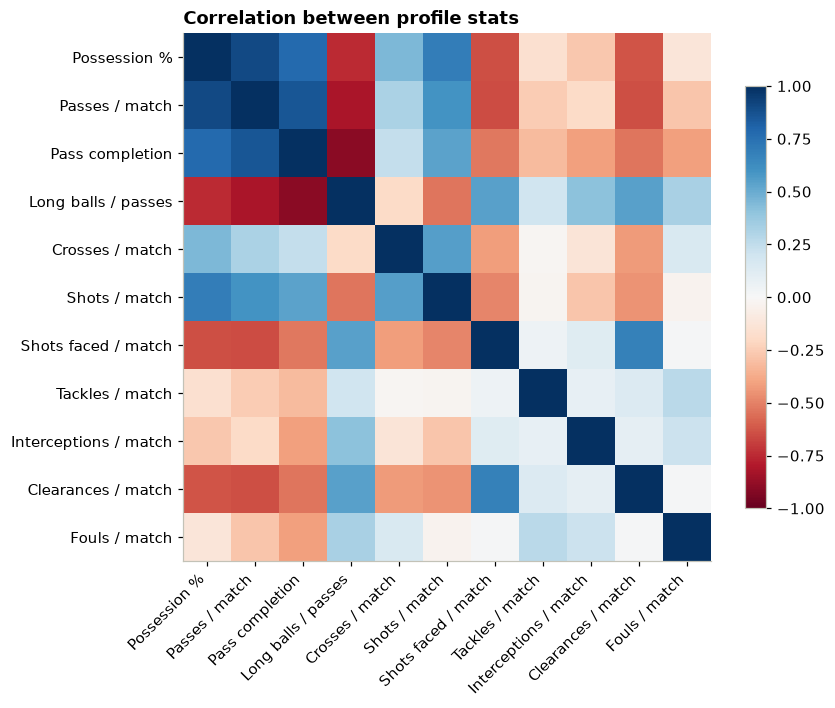

In [3]:
corr = profiles[list(PROFILE_FEATURES)].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
image = ax.imshow(corr.values, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), [PROFILE_FEATURES[c] for c in corr.columns], rotation=45, ha="right")
ax.set_yticks(range(len(corr)), [PROFILE_FEATURES[c] for c in corr.index])
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8)
ax.set_title("Correlation between profile stats")
plt.tight_layout()
corr.loc["possession_pct"].sort_values().round(2)

Possession is tied up with almost everything: 0.90 with passes, 0.78 with pass completion and 0.70 with shots,
and strongly negative with long-ball share (-0.75), shots faced (-0.64) and clearances (-0.63). So a lot of
these eleven stats are really measuring one thing: how much a club controls the game. Tackles, interceptions
and fouls barely relate to possession, so they add a bit of independent information.

Expect the clustering to split mainly along that control axis.

## How many clusters?

,k,silhouette
0,2,0.251
1,3,0.177
2,4,0.159
3,5,0.142
4,6,0.144
5,7,0.143
6,8,0.138


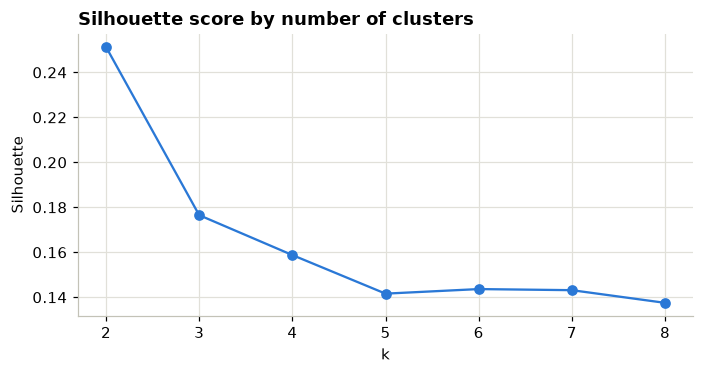

In [4]:
result = cluster_profiles(profiles)
silhouettes = result["silhouettes"]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(silhouettes["k"], silhouettes["silhouette"], marker="o", color=BLUE)
ax.set(title="Silhouette score by number of clusters", xlabel="k", ylabel="Silhouette")
plt.tight_layout()
silhouettes.round(3)

Two clusters score best, but a silhouette of 0.25 is weak: the groups overlap a lot. From three clusters up
the score drops to around 0.14 to 0.18, which means there's no natural finer split. Club styles look more
like a spectrum than a set of boxes, and two groups is the most we can defend.

In [5]:
centres = result["centres"]
for i in centres.index:
    print(f"Cluster {i} ({centres.loc[i, 'clubs']} club-seasons): {describe_cluster(centres.loc[i])}")
centres[list(PROFILE_FEATURES)].round(2)

Cluster 1 (125 club-seasons): Higher pass completion and passes / match; lower long balls / passes and clearances / match than average
Cluster 2 (139 club-seasons): Higher long balls / passes and clearances / match; lower pass completion and passes / match than average


,possession_pct,passes,pass_completion,long_ball_share,crosses,shots,shots_against,tackles,interceptions,clearances,fouls
1,0.76,0.78,0.79,-0.77,0.43,0.62,-0.57,-0.30,-0.34,-0.58,-0.21
2,-0.68,-0.70,-0.71,0.69,-0.38,-0.55,0.51,0.27,0.31,0.52,0.19


## Are the clusters stable?

Re-run k-means with different random starts and different subsets of club-seasons, and measure agreement
with the original labels using the adjusted Rand index (1 = identical, 0 = no better than chance).

In [6]:
scaled, _ = standardize(profiles)
base_labels = result["profiles"]["cluster"].to_numpy()
rng = np.random.default_rng(0)

seed_scores, sample_scores = [], []
for seed in range(20):
    labels = KMeans(n_clusters=result["k"], n_init=20, random_state=seed).fit_predict(scaled)
    seed_scores.append(adjusted_rand_score(base_labels, labels))

    keep = rng.choice(len(scaled), size=int(0.8 * len(scaled)), replace=False)
    model = KMeans(n_clusters=result["k"], n_init=20, random_state=seed).fit(scaled[keep])
    sample_scores.append(adjusted_rand_score(base_labels, model.predict(scaled)))

print(f"Different random starts: mean ARI {np.mean(seed_scores):.3f}")
print(f"Fitted on 80% subsets:    mean ARI {np.mean(sample_scores):.3f}, lowest {np.min(sample_scores):.3f}")

Different random starts: mean ARI 0.994
Fitted on 80% subsets:    mean ARI 0.891, lowest 0.745


## Does style relate to results?

In [7]:
results = club_matches[club_matches["season_year"] >= 2018].groupby(["season_year", "club_id"]).agg(
    points=("points", "mean"), goal_diff=("goals_for", "mean")
).reset_index()
merged = result["profiles"].merge(results, on=["season_year", "club_id"])
merged.groupby("cluster")[["points", "possession_pct", "passes", "shots_against"]].mean().round(2)

,points,possession_pct,passes,shots_against
cluster,,,,
1,1.65,54.52,550.13,11.48
2,0.94,43.54,412.60,15.02


The labels are stable to random starts (mean ARI 0.99) and fairly stable when 20% of club-seasons are left
out (mean 0.89, lowest 0.75), so the two groups aren't an accident of one run.

The control cluster averages 1.65 points per match against 0.94 for the other. That's a big gap, but it
doesn't mean possession wins games. Better squads get more of the ball because they're better, and weaker
sides sit deeper against them. The cluster mostly tells us which side of that relationship a club is on.

## Conclusion

- Most of the profile variation is one control axis (possession, passes, fewer clearances and long balls).
- Two clusters is the best k by silhouette, but the separation is weak, so they're described in the
  dashboard as statistical groups, not tactical identities.
- The clusters are stable, and strongly linked to results, but that link is correlation, not cause.
- Pressing, progressive passing and final-third data would make this much more interesting; ESPN doesn't have them.